In [4]:
# Traffic Demand Prediction using CatBoost

#Objective

#Predict urban traffic demand using spatio-temporal, road network, and environmental features.

#Dataset:
#- Train: 77,299 rows
#- Test: 41,778 rows

#Evaluation Metric:
#- R² Score"""

In [5]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample = pd.read_csv("sample_submission.csv")

In [6]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

train.head()

Train Shape: (77299, 11)
Test Shape: (41778, 10)


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [7]:
# Exploratory Data Analysis

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [9]:
train.isnull().sum()

,0
Index,0
geohash,0
day,0
timestamp,0
demand,0
RoadType,600
NumberofLanes,0
LargeVehicles,0
Landmarks,0
Temperature,2495


In [10]:
train["demand"].describe()

,demand
count,7.729900e+04
mean,9.394238e-02
std,1.421905e-01
min,6.245650e-07
25%,1.822723e-02
50%,4.775994e-02
75%,1.085951e-01
max,1.000000e+00


In [11]:
train.groupby("Weather")["demand"].mean()

,demand
Weather,
Foggy,0.093372
Rainy,0.094471
Snowy,0.092581
Sunny,0.094247


In [12]:
train.groupby("NumberofLanes")["demand"].mean()

,demand
NumberofLanes,
1,0.088104
2,0.077488
3,0.077859
4,0.602882
5,0.607556


In [13]:
train.groupby("RoadType")["demand"].mean()

,demand
RoadType,
Highway,0.610756
Residential,0.057209
Street,0.273164


In [14]:
train.groupby("Landmarks")["demand"].mean()

,demand
Landmarks,
No,0.096295
Yes,0.092801


In [15]:
train["geohash"].nunique()

1249

In [16]:
# Data Cleaning

In [17]:
train_clean = train.copy()
test_clean = test.copy()

In [18]:
train_clean["RoadType"] = train_clean["RoadType"].fillna("Residential")
test_clean["RoadType"] = test_clean["RoadType"].fillna("Residential")

In [19]:
train_clean["Weather"] = train_clean["Weather"].fillna("Sunny")
test_clean["Weather"] = test_clean["Weather"].fillna("Sunny")

In [20]:
train_clean["Temperature"] = train_clean["Temperature"].fillna(
    train_clean["Temperature"].median()
)

test_clean["Temperature"] = test_clean["Temperature"].fillna(
    train_clean["Temperature"].median()
)

In [21]:
# Feature Engineering

In [22]:
train_clean[['hour','minute']] = train_clean['timestamp'].str.split(':', expand=True)
test_clean[['hour','minute']] = test_clean['timestamp'].str.split(':', expand=True)

train_clean['hour'] = train_clean['hour'].astype(int)
train_clean['minute'] = train_clean['minute'].astype(int)

test_clean['hour'] = test_clean['hour'].astype(int)
test_clean['minute'] = test_clean['minute'].astype(int)

In [23]:
train_clean["rush_hour"] = (
    ((train_clean["hour"] >= 7) & (train_clean["hour"] <= 10))
).astype(int)

test_clean["rush_hour"] = (
    ((test_clean["hour"] >= 7) & (test_clean["hour"] <= 10))
).astype(int)

In [24]:
train_clean["evening_peak"] = (
    ((train_clean["hour"] >= 17) & (train_clean["hour"] <= 20))
).astype(int)

test_clean["evening_peak"] = (
    ((test_clean["hour"] >= 17) & (test_clean["hour"] <= 20))
).astype(int)

In [25]:
train_clean["geohash_prefix4"] = train_clean["geohash"].str[:4]
test_clean["geohash_prefix4"] = test_clean["geohash"].str[:4]

In [26]:
train_clean = train_clean.drop("timestamp", axis=1)
test_clean = test_clean.drop("timestamp", axis=1)

In [27]:
# Model Training

In [28]:
X = train_clean.drop(["demand","Index"], axis=1)
y = train_clean["demand"]

X_test = test_clean.drop("Index", axis=1)

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
!pip install catboost -q

from catboost import CatBoostRegressor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [31]:
cat_features = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather",
    "geohash_prefix4"
]

In [32]:
model_v5 = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    verbose=200
)

model_v5.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid)
)

0:	learn: 0.1389964	test: 0.1390061	best: 0.1390061 (0)	total: 195ms	remaining: 6m 28s
200:	learn: 0.0423096	test: 0.0415744	best: 0.0415744 (200)	total: 15.1s	remaining: 2m 15s
400:	learn: 0.0385374	test: 0.0388188	best: 0.0388188 (400)	total: 30.2s	remaining: 2m
600:	learn: 0.0364900	test: 0.0374729	best: 0.0374729 (600)	total: 45.9s	remaining: 1m 46s
800:	learn: 0.0348325	test: 0.0365532	best: 0.0365532 (800)	total: 1m 1s	remaining: 1m 31s
1000:	learn: 0.0336197	test: 0.0357174	best: 0.0357173 (999)	total: 1m 18s	remaining: 1m 18s
1200:	learn: 0.0326791	test: 0.0350936	best: 0.0350936 (1200)	total: 1m 33s	remaining: 1m 2s
1400:	learn: 0.0318888	test: 0.0346732	best: 0.0346732 (1400)	total: 1m 49s	remaining: 46.9s
1600:	learn: 0.0312436	test: 0.0343677	best: 0.0343677 (1600)	total: 2m 5s	remaining: 31.3s
1800:	learn: 0.0305984	test: 0.0340431	best: 0.0340431 (1800)	total: 2m 24s	remaining: 16s
1999:	learn: 0.0300869	test: 0.0337773	best: 0.0337772 (1997)	total: 2m 40s	remaining: 0us


CatBoostRegressor(depth=8, iterations=2000, learning_rate=0.03, loss_function='RMSE', verbose=200)

In [33]:
# Evaluation

In [41]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

valid_preds = model_v5.predict(X_valid)

r2 = r2_score(y_valid, valid_preds)
mae = mean_absolute_error(y_valid, valid_preds)
rmse = np.sqrt(mean_squared_error(y_valid, valid_preds))

print(f"Validation R² Score : {r2:.6f}")
print(f"Validation MAE      : {mae:.6f}")
print(f"Validation RMSE     : {rmse:.6f}")

Validation R² Score : 0.943616
Validation MAE      : 0.021793
Validation RMSE     : 0.033777


In [42]:
feature_importance = model_v5.get_feature_importance()

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance
})

importance_df.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
2,RoadType,59.975210
0,geohash,12.254027
3,NumberofLanes,10.104283
8,hour,7.732942
4,LargeVehicles,4.161790
12,geohash_prefix4,2.945184
11,evening_peak,0.836907
1,day,0.825411
6,Temperature,0.375641
9,minute,0.252664


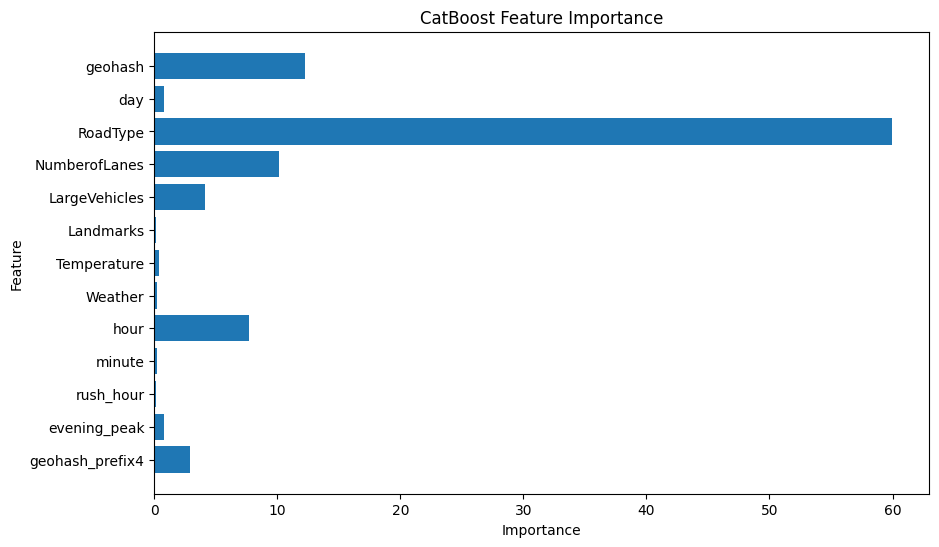

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance")

plt.show()

In [44]:
# Train on Full Dataset

In [45]:
X_full = train_clean.drop(["demand","Index"], axis=1)
y_full = train_clean["demand"]

In [46]:
model_v5_full = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    verbose=200
)

model_v5_full.fit(
    X_full,
    y_full,
    cat_features=cat_features
)

0:	learn: 0.1389901	total: 106ms	remaining: 3m 31s
200:	learn: 0.0414604	total: 15.5s	remaining: 2m 18s
400:	learn: 0.0384846	total: 31.5s	remaining: 2m 5s
600:	learn: 0.0365508	total: 56.5s	remaining: 2m 11s
800:	learn: 0.0350783	total: 1m 13s	remaining: 1m 50s
1000:	learn: 0.0339503	total: 1m 32s	remaining: 1m 32s
1200:	learn: 0.0329767	total: 1m 49s	remaining: 1m 12s
1400:	learn: 0.0321450	total: 2m 7s	remaining: 54.5s
1600:	learn: 0.0314559	total: 2m 27s	remaining: 36.7s
1800:	learn: 0.0308570	total: 2m 44s	remaining: 18.2s
1999:	learn: 0.0303695	total: 3m 3s	remaining: 0us


CatBoostRegressor(depth=8, iterations=2000, learning_rate=0.03, loss_function='RMSE', verbose=200)

In [39]:
test_preds_v5 = model_v5_full.predict(X_test)

In [40]:
submission = pd.DataFrame({
    "Index": test["Index"],
    "demand": test_preds_v5
})

submission.to_csv("submission.csv", index=False)

submission.head()

,Index,demand
0,0,0.037296
1,1,0.022206
2,2,0.009184
3,3,0.029520
4,4,0.048661
